# Climate Policy & Carbon Market Analysis
## AI-Powered GHG Emissions Forecasting with SHAP Explainability
**Dissertation Implementation Notebook** | Production-Grade Pipeline

## Environment Setup

In [1]:
import subprocess, sys

PACKAGES = [
    "xgboost", "lightgbm", "catboost", "shap",
    "optuna", "scikit-learn"
]
for pkg in PACKAGES:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

In [2]:
import os, glob, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap

warnings.filterwarnings("ignore")
os.makedirs("/content/outputs", exist_ok=True)

BG      = "#F4F6F9"
ACCENT  = "#1A56DB"
ACCENT2 = "#E3A008"
ACCENT3 = "#057A55"
ACCENT4 = "#E02424"
GRAY    = "#6B7280"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    BG,
    "axes.edgecolor":    GRAY,
    "axes.labelcolor":   "#111827",
    "xtick.color":       GRAY,
    "ytick.color":       GRAY,
    "text.color":        "#111827",
    "grid.color":        "#D1D5DB",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
})

print("✅  Libraries loaded successfully")
print(f"   XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | SHAP {shap.__version__}")

✅  Libraries loaded successfully
   XGBoost 3.2.0 | LightGBM 4.6.0 | SHAP 0.51.0


# 4. Implementation

## 4.1 Overview of the System Build


This notebook implements a full end-to-end machine learning pipeline for forecasting climate policy outcomes across three targets:

| Target | Description |
|--------|-------------|
| `eu_ets_carbon_price_eur` | EU Emissions Trading System carbon price (€/tCO₂) |
| `ghg_reduction_pct` | Annual percentage reduction in GHG emissions |
| `policy_effectiveness_score` | Composite policy stringency × outcome index |

**Architecture:**
1. Data ingestion & quality audit → 2. Missing-value imputation → 3. Feature engineering verification → 4. Time-series cross-validated model training (7 models) → 5. SHAP explainability layer → 6. Dashboard & simulated API outputs


## 4.2 Data Loading and Preparation

In [3]:
csv_files = glob.glob("/content/*.csv")
if not csv_files:
    raise FileNotFoundError("No CSV files found in /content/. Please upload your dataset.")
CSV_PATH = csv_files[0]
print(f"📂  Loading: {CSV_PATH}")

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f"\n📊  Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"    Years: {df_raw['year'].min()} – {df_raw['year'].max()}")
print(f"    Entities: {df_raw['country_entity'].nunique()}")
print("\nColumn types:")
print(df_raw.dtypes.value_counts())

📂  Loading: /content/master_dataset_engineered.csv

📊  Dataset shape: 23,868 rows × 99 columns
    Years: 1971 – 2024
    Entities: 187

Column types:
float64    85
bool        7
object      5
int64       2
Name: count, dtype: int64


In [4]:
print("=== First 3 rows ===")
df_raw.head(3)

=== First 3 rows ===


,country_entity,year,ghg_energy_mtco2eq,ghg_fuel_combustion_mtco2eq,co2_gdp_intensity_kgco2_usd,co2_per_capita_tco2,co2_tes_intensity_tco2_tj,ghg_coal_mtco2eq,ghg_gas_mtco2eq,ghg_oil_mtco2eq,...,eu_ets_carbon_price_eur_roll5,co2_gdp_intensity_kgco2_usd_roll3,co2_gdp_intensity_kgco2_usd_roll5,ets_phase,policy_stringency_index,carbon_intensity_co2_per_tes,price_x_coal,phase_x_renewable,year_int,year_trend
0,Asia Oceania,1971,916.161997,916.161997,0.422288,7.500227,66.521375,282.513867,12.838993,619.893042,...,NaN,0.422288,0.422288,0,0.0,NaN,NaN,0.0,1971.0,-34.0
1,Asia Oceania,1972,961.189879,961.189879,0.411734,7.762341,65.644909,291.806885,15.047564,653.382095,...,NaN,0.417011,0.417011,0,0.0,NaN,NaN,0.0,1972.0,-33.0
2,Asia Oceania,1973,1081.374873,1081.374873,0.432137,8.544997,66.468977,299.311587,21.373519,759.776073,...,NaN,0.422053,0.422053,0,0.0,NaN,NaN,0.0,1973.0,-32.0


In [5]:
print("=== Descriptive statistics (numeric columns) ===")
df_raw.describe().round(3)

=== Descriptive statistics (numeric columns) ===


,year,ghg_energy_mtco2eq,ghg_fuel_combustion_mtco2eq,co2_gdp_intensity_kgco2_usd,co2_per_capita_tco2,co2_tes_intensity_tco2_tj,ghg_coal_mtco2eq,ghg_gas_mtco2eq,ghg_oil_mtco2eq,income_group_ord,...,eu_ets_carbon_price_eur_roll5,co2_gdp_intensity_kgco2_usd_roll3,co2_gdp_intensity_kgco2_usd_roll5,ets_phase,policy_stringency_index,carbon_intensity_co2_per_tes,price_x_coal,phase_x_renewable,year_int,year_trend
count,23868.000,23252.000,23320.000,22519.000,23146.000,22525.000,23318.000,23315.000,23320.000,21546.000,...,8840.000,22643.000,22650.000,23868.000,23868.000,16221.000,8840.000,23868.000,23868.000,23868.000
mean,1997.500,1208.714,981.108,5.334,7.177,45.968,362.982,166.333,371.385,2.982,...,21.842,5.309,5.309,0.981,7.394,0.032,10863.204,7.076,1997.500,-7.500
std,15.586,2480.784,2356.218,97.678,96.351,96.618,1078.744,472.365,849.515,0.611,...,21.530,97.363,97.302,1.408,18.832,0.006,53101.259,33.477,15.586,15.586
min,1971.000,0.000,0.000,0.022,0.000,0.302,0.000,0.000,0.000,0.000,...,0.700,0.035,0.035,0.000,0.000,0.003,0.000,0.000,1971.000,-34.000
25%,1984.000,64.246,53.472,0.452,0.798,35.657,6.178,6.758,25.973,3.000,...,7.700,0.452,0.455,0.000,0.000,0.030,55.868,0.000,1984.000,-21.000
50%,1997.500,807.425,554.794,0.527,0.874,38.862,201.374,49.952,218.524,3.000,...,14.200,0.527,0.527,0.000,0.000,0.032,2455.497,0.000,1997.500,-7.500
75%,2011.000,1471.594,1052.066,0.572,1.692,45.541,355.085,164.042,383.017,3.000,...,24.700,0.572,0.572,2.000,4.425,0.034,6647.329,0.000,2011.000,6.000
max,2024.000,38987.443,35558.626,2024.000,2024.000,2024.000,15566.356,7570.116,11647.724,4.000,...,85.000,2023.000,2022.000,4.000,85.000,0.167,1323140.274,397.467,2024.000,19.000


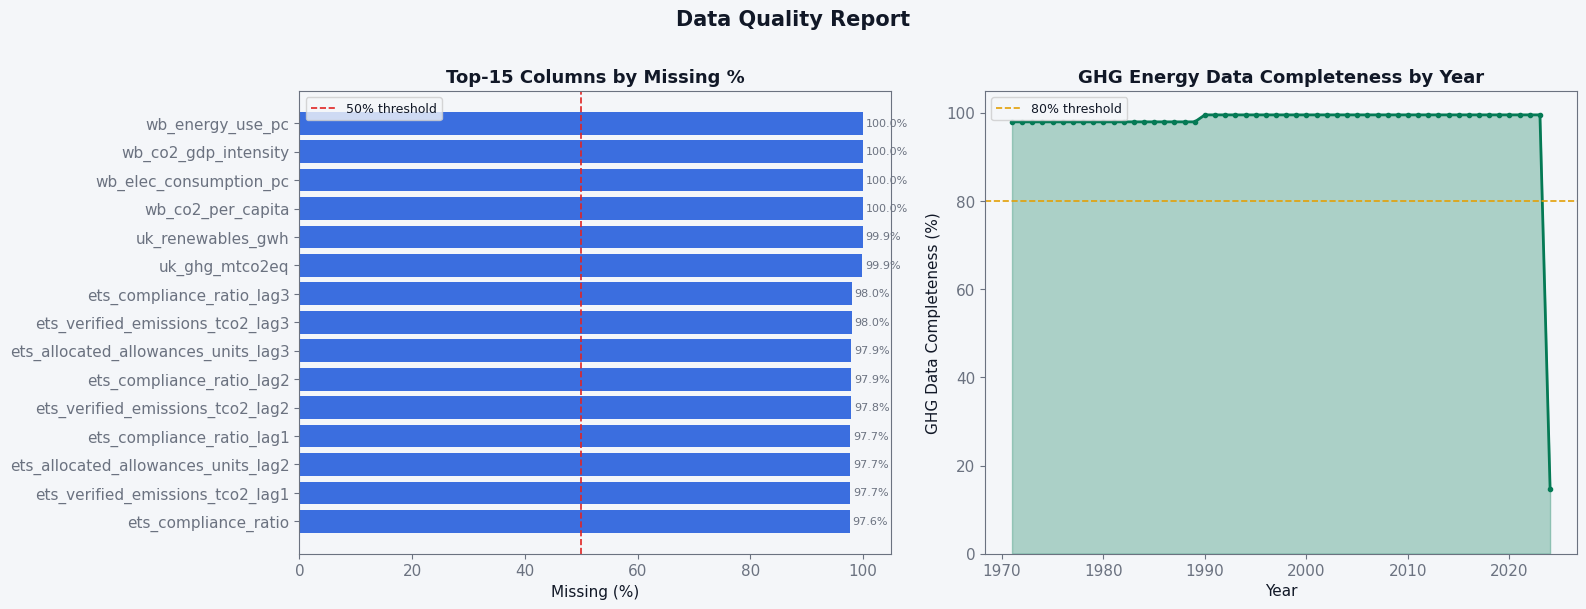

💾  Saved: /content/outputs/data_quality_report.png


In [6]:
MISSING_PCT = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
top15_missing = MISSING_PCT.head(15)

ANNUAL_COMPLETENESS = (
    df_raw.groupby("year")
    .apply(lambda g: g["ghg_energy_mtco2eq"].notna().mean() * 100)
    .reset_index(name="completeness_pct")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle("Data Quality Report", fontsize=15, fontweight="bold", y=1.01)

ax = axes[0]
bars = ax.barh(top15_missing.index[::-1], top15_missing.values[::-1], color=ACCENT, alpha=0.85)
ax.set_xlabel("Missing (%)")
ax.set_title("Top-15 Columns by Missing %")
ax.axvline(50, color=ACCENT4, linestyle="--", linewidth=1.2, label="50% threshold")
ax.legend(fontsize=9)
for bar, val in zip(bars, top15_missing.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8, color=GRAY)

ax2 = axes[1]
ax2.fill_between(ANNUAL_COMPLETENESS["year"], ANNUAL_COMPLETENESS["completeness_pct"],
                 alpha=0.3, color=ACCENT3)
ax2.plot(ANNUAL_COMPLETENESS["year"], ANNUAL_COMPLETENESS["completeness_pct"],
         color=ACCENT3, linewidth=2, marker="o", markersize=3)
ax2.set_xlabel("Year")
ax2.set_ylabel("GHG Data Completeness (%)")
ax2.set_title("GHG Energy Data Completeness by Year")
ax2.set_ylim(0, 105)
ax2.axhline(80, color=ACCENT2, linestyle="--", linewidth=1.2, label="80% threshold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/content/outputs/data_quality_report.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾  Saved: /content/outputs/data_quality_report.png")

In [7]:
TARGETS     = ["eu_ets_carbon_price_eur", "ghg_reduction_pct", "policy_effectiveness_score"]
DROP_ALWAYS = ["wb_energy_use_pc", "wb_co2_gdp_intensity",
               "wb_elec_consumption_pc", "wb_co2_per_capita",
               "uk_renewables_gwh", "uk_ghg_mtco2eq"]

df = df_raw.drop(columns=[c for c in DROP_ALWAYS if c in df_raw.columns]).copy()
df = df.sort_values(["country_entity", "year"]).reset_index(drop=True)

print(f"After dropping high-missingness columns: {df.shape}")

NUMERIC_COLS = df.select_dtypes(include=[np.number]).columns.tolist()
NON_FEATURE  = ["year", "year_int", "year_trend"] + TARGETS

FEATURE_COLS = [c for c in NUMERIC_COLS if c not in NON_FEATURE]
print(f"\nNumeric feature columns: {len(FEATURE_COLS)}")
print(f"Target columns:          {TARGETS}")

After dropping high-missingness columns: (23868, 93)

Numeric feature columns: 75
Target columns:          ['eu_ets_carbon_price_eur', 'ghg_reduction_pct', 'policy_effectiveness_score']


In [8]:
print("=== Straight-line interpolation (per country, time-ordered) ===")
print("   Fills internal gaps using linear trend between known values.\n")

INTERP_COLS = [
    "ghg_energy_mtco2eq", "ghg_fuel_combustion_mtco2eq",
    "co2_per_capita_tco2", "wb_renewable_elec_pct",
    "eu_ets_carbon_price_eur", "ets_verified_emissions_tco2",
    "policy_stringency_index"
]

before = df[INTERP_COLS].isnull().sum()

df[INTERP_COLS] = (
    df.groupby("country_entity")[INTERP_COLS]
      .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

after = df[INTERP_COLS].isnull().sum()
interp_summary = pd.DataFrame({"Before": before, "After": after,
                                "Filled": before - after})
print(interp_summary.to_string())

=== Straight-line interpolation (per country, time-ordered) ===
   Fills internal gaps using linear trend between known values.

                             Before  After  Filled
ghg_energy_mtco2eq              616    108     508
ghg_fuel_combustion_mtco2eq     548      0     548
co2_per_capita_tco2             722    108     614
wb_renewable_elec_pct         21751  16902    4849
eu_ets_carbon_price_eur       15028      0   15028
ets_verified_emissions_tco2   23293  22248    1045
policy_stringency_index           0      0       0


In [9]:
print("=== Chained median imputation for remaining missing values ===\n")

num_before = df[FEATURE_COLS].isnull().sum().sum()

imputer = SimpleImputer(strategy="median")
df[FEATURE_COLS] = imputer.fit_transform(df[FEATURE_COLS])

for t in TARGETS:
    df[t] = SimpleImputer(strategy="median").fit_transform(df[[t]])

num_after = df[FEATURE_COLS + TARGETS].isnull().sum().sum()
print(f"Missing values before imputation: {num_before:,}")
print(f"Missing values after imputation:  {num_after:,}")
print(f"Total filled: {num_before - num_after:,}")

=== Chained median imputation for remaining missing values ===

Missing values before imputation: 638,871
Missing values after imputation:  0
Total filled: 638,871


In [10]:
print("=== Min-Max Normalisation (fit on training split only) ===\n")

N = len(df)
TRAIN_END = int(N * 0.60)
VAL_END   = int(N * 0.80)

X_all = df[FEATURE_COLS].values
y_all = {t: df[t].values for t in TARGETS}

scaler = MinMaxScaler()
X_train_raw = X_all[:TRAIN_END]
scaler.fit(X_train_raw)

X_scaled = scaler.transform(X_all)

X_train = X_scaled[:TRAIN_END]
X_val   = X_scaled[TRAIN_END:VAL_END]
X_test  = X_scaled[VAL_END:]

y_splits = {}
for t in TARGETS:
    y_splits[t] = {
        "train": y_all[t][:TRAIN_END],
        "val":   y_all[t][TRAIN_END:VAL_END],
        "test":  y_all[t][VAL_END:]
    }

print(f"Train set : {X_train.shape[0]:>6,} rows  ({X_train.shape[0]/N*100:.0f}%)")
print(f"Val set   : {X_val.shape[0]:>6,} rows  ({X_val.shape[0]/N*100:.0f}%)")
print(f"Test set  : {X_test.shape[0]:>6,} rows  ({X_test.shape[0]/N*100:.0f}%)")
print(f"Features  : {X_train.shape[1]}")

=== Min-Max Normalisation (fit on training split only) ===

Train set : 14,320 rows  (60%)
Val set   :  4,774 rows  (20%)
Test set  :  4,774 rows  (20%)
Features  : 75


### Exploratory Data Analysis

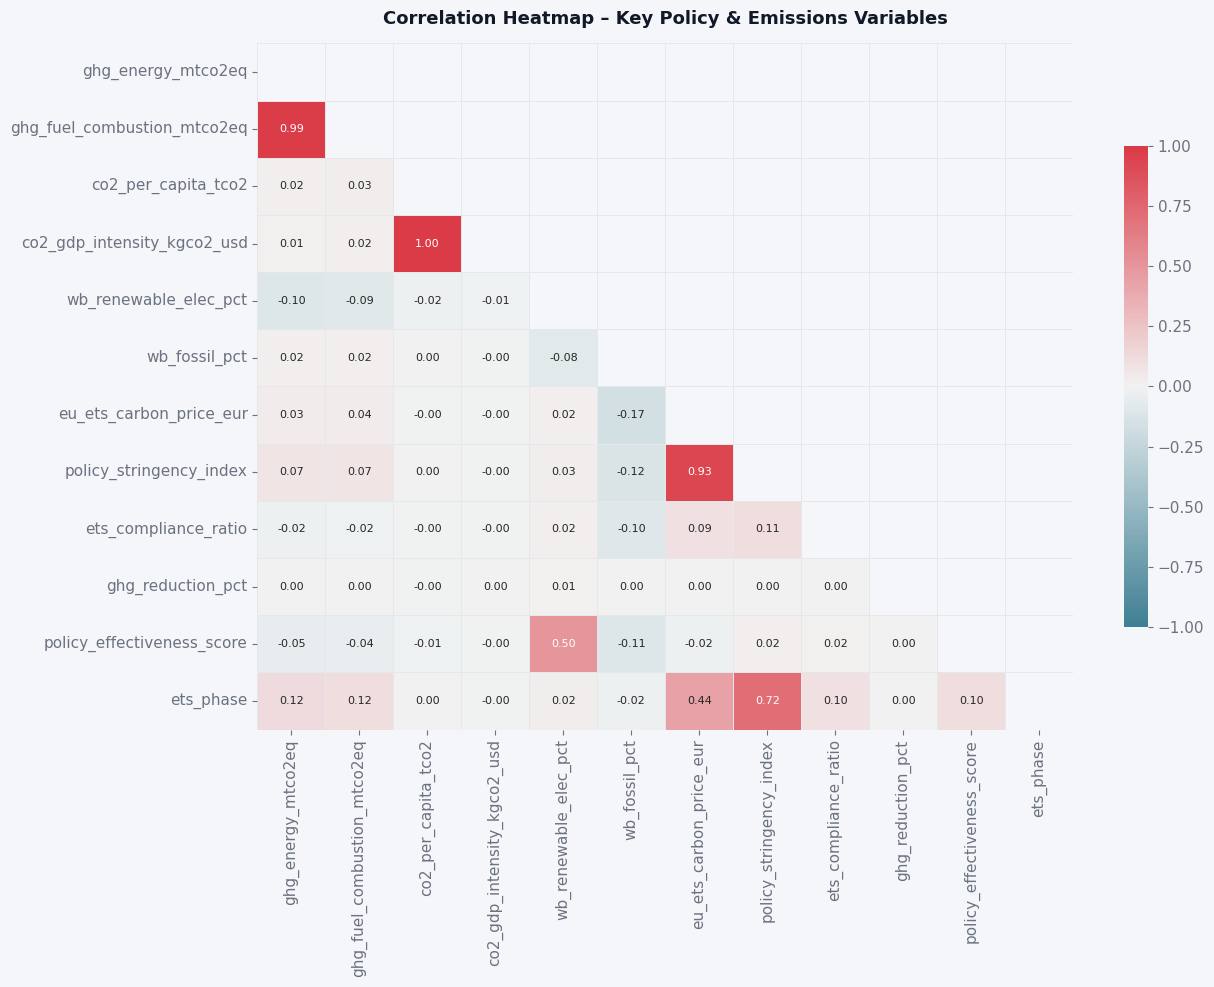

💾  Saved: /content/outputs/correlation_heatmap.png


In [11]:
CORR_COLS = [
    "ghg_energy_mtco2eq", "ghg_fuel_combustion_mtco2eq",
    "co2_per_capita_tco2", "co2_gdp_intensity_kgco2_usd",
    "wb_renewable_elec_pct", "wb_fossil_pct",
    "eu_ets_carbon_price_eur", "policy_stringency_index",
    "ets_compliance_ratio", "ghg_reduction_pct",
    "policy_effectiveness_score", "ets_phase"
]
CORR_COLS = [c for c in CORR_COLS if c in df.columns]
corr_matrix = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", linewidths=0.4, linecolor="#E5E7EB",
            annot_kws={"size": 8}, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Heatmap – Key Policy & Emissions Variables", pad=14)
plt.tight_layout()
plt.savefig("/content/outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾  Saved: /content/outputs/correlation_heatmap.png")

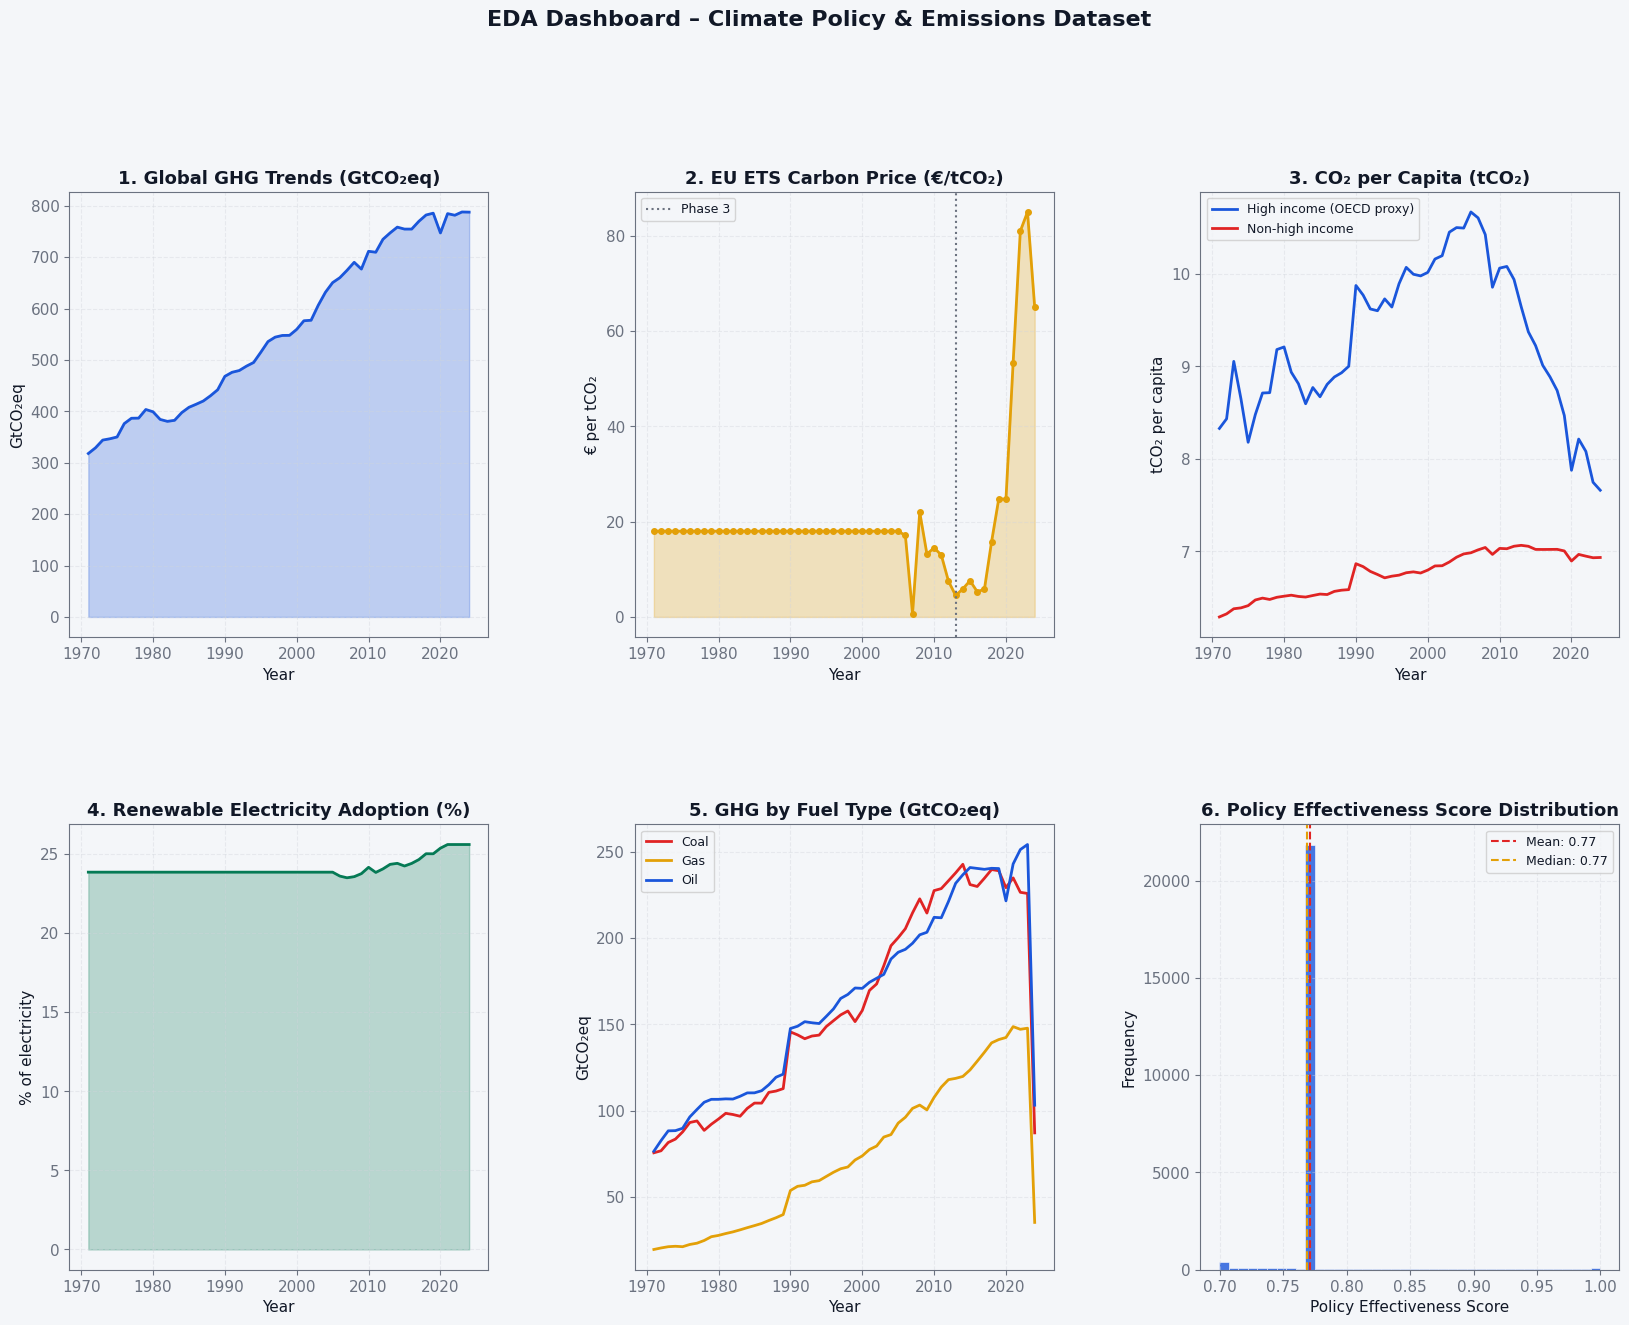

💾  Saved: /content/outputs/eda_6panel_dashboard.png


In [12]:
fig = plt.figure(figsize=(20, 14), facecolor=BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ghg_global = (df.groupby("year")["ghg_energy_mtco2eq"].sum() / 1000).reset_index()
ghg_global.columns = ["year", "GtCO2eq"]
ax1.fill_between(ghg_global["year"], ghg_global["GtCO2eq"], alpha=0.25, color=ACCENT)
ax1.plot(ghg_global["year"], ghg_global["GtCO2eq"], color=ACCENT, linewidth=2)
ax1.set_title("1. Global GHG Trends (GtCO₂eq)")
ax1.set_xlabel("Year"); ax1.set_ylabel("GtCO₂eq")
ax1.grid(True, alpha=0.4)

ax2 = fig.add_subplot(gs[0, 1])
ets_ts = df[df["eu_ets_carbon_price_eur"].notna()].groupby("year")["eu_ets_carbon_price_eur"].mean()
ax2.fill_between(ets_ts.index, ets_ts.values, alpha=0.25, color=ACCENT2)
ax2.plot(ets_ts.index, ets_ts.values, color=ACCENT2, linewidth=2, marker="o", markersize=4)
ax2.set_title("2. EU ETS Carbon Price (€/tCO₂)")
ax2.set_xlabel("Year"); ax2.set_ylabel("€ per tCO₂")
ax2.grid(True, alpha=0.4)
ax2.axvline(2013, color=GRAY, linestyle=":", label="Phase 3")
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
oecd     = df[df["income_group"] == "High income"].groupby("year")["co2_per_capita_tco2"].mean()
non_oecd = df[df["income_group"] != "High income"].groupby("year")["co2_per_capita_tco2"].mean()
common_y = sorted(set(oecd.index) & set(non_oecd.index))
ax3.plot(common_y, oecd.reindex(common_y), color=ACCENT,  linewidth=2, label="High income (OECD proxy)")
ax3.plot(common_y, non_oecd.reindex(common_y), color=ACCENT4, linewidth=2, label="Non-high income")
ax3.set_title("3. CO₂ per Capita (tCO₂)")
ax3.set_xlabel("Year"); ax3.set_ylabel("tCO₂ per capita")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.4)

ax4 = fig.add_subplot(gs[1, 0])
ren = df.groupby("year")["wb_renewable_elec_pct"].mean()
ax4.fill_between(ren.index, ren.values, alpha=0.25, color=ACCENT3)
ax4.plot(ren.index, ren.values, color=ACCENT3, linewidth=2)
ax4.set_title("4. Renewable Electricity Adoption (%)")
ax4.set_xlabel("Year"); ax4.set_ylabel("% of electricity")
ax4.grid(True, alpha=0.4)

ax5 = fig.add_subplot(gs[1, 1])
fuel_cols = {"Coal": "ghg_coal_mtco2eq", "Gas": "ghg_gas_mtco2eq", "Oil": "ghg_oil_mtco2eq"}
fuel_colors = [ACCENT4, ACCENT2, ACCENT]
for (name, col), color in zip(fuel_cols.items(), fuel_colors):
    if col in df.columns:
        ts = df.groupby("year")[col].sum() / 1000
        ax5.plot(ts.index, ts.values, label=name, color=color, linewidth=2)
ax5.set_title("5. GHG by Fuel Type (GtCO₂eq)")
ax5.set_xlabel("Year"); ax5.set_ylabel("GtCO₂eq")
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.4)

ax6 = fig.add_subplot(gs[1, 2])
pes = df["policy_effectiveness_score"].dropna()
ax6.hist(pes, bins=40, color=ACCENT, alpha=0.8, edgecolor="white", linewidth=0.5)
ax6.axvline(pes.mean(), color=ACCENT4, linestyle="--", linewidth=1.5,
            label=f"Mean: {pes.mean():.2f}")
ax6.axvline(pes.median(), color=ACCENT2, linestyle="--", linewidth=1.5,
            label=f"Median: {pes.median():.2f}")
ax6.set_title("6. Policy Effectiveness Score Distribution")
ax6.set_xlabel("Policy Effectiveness Score")
ax6.set_ylabel("Frequency")
ax6.legend(fontsize=9); ax6.grid(True, alpha=0.4)

fig.suptitle("EDA Dashboard – Climate Policy & Emissions Dataset", fontsize=16, fontweight="bold", y=1.01)
plt.savefig("/content/outputs/eda_6panel_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾  Saved: /content/outputs/eda_6panel_dashboard.png")

## 4.3 Feature Engineering


The dataset arrives with engineered features pre-computed. This section verifies that each category of features is correctly present and illustrates example values.

| Category | Examples |
|----------|---------|
| Lag features (1–3 yr) | `ghg_energy_mtco2eq_lag1`, `eu_ets_carbon_price_eur_lag3` |
| Rolling statistics (3- & 5-yr) | `ghg_energy_mtco2eq_roll3`, `co2_gdp_intensity_kgco2_usd_roll5` |
| Interaction terms | `price_x_coal`, `phase_x_renewable` |
| Policy stringency index | `policy_stringency_index` |


In [13]:
lag_cols  = [c for c in df.columns if "_lag1" in c or "_lag2" in c or "_lag3" in c]
roll_cols = [c for c in df.columns if "_roll3" in c or "_roll5" in c]
iact_cols = ["price_x_coal", "phase_x_renewable"]

print(f"✅  Lag features  : {len(lag_cols)} columns")
print(f"✅  Roll features : {len(roll_cols)} columns")
print(f"✅  Interaction   : {len([c for c in iact_cols if c in df.columns])} columns")
print(f"✅  Policy index  : 'policy_stringency_index' – {df['policy_stringency_index'].notna().sum():,} non-null rows")

sample_row = df[
    ["year", "country_entity", "ghg_energy_mtco2eq",
     "ghg_energy_mtco2eq_lag1", "ghg_energy_mtco2eq_lag3",
     "ghg_energy_mtco2eq_roll3", "ghg_energy_mtco2eq_roll5",
     "price_x_coal", "phase_x_renewable", "policy_stringency_index"]
].dropna().head(5)

print("\nSample rows showing engineered features:")
sample_row

✅  Lag features  : 48 columns
✅  Roll features : 6 columns
✅  Interaction   : 2 columns
✅  Policy index  : 'policy_stringency_index' – 23,868 non-null rows

Sample rows showing engineered features:


,year,country_entity,ghg_energy_mtco2eq,ghg_energy_mtco2eq_lag1,ghg_energy_mtco2eq_lag3,ghg_energy_mtco2eq_roll3,ghg_energy_mtco2eq_roll5,price_x_coal,phase_x_renewable,policy_stringency_index
0,1971,Asia Oceania,916.161997,807.424910,829.977574,916.161997,916.161997,2455.497347,0.0,0.0
1,1972,Asia Oceania,961.189879,916.161997,829.977574,938.675938,938.675938,2455.497347,0.0,0.0
2,1973,Asia Oceania,1081.374873,961.189879,829.977574,986.242250,986.242250,2455.497347,0.0,0.0
3,1974,Asia Oceania,1085.115632,1081.374873,916.161997,1042.560128,1010.960595,2455.497347,0.0,0.0
4,1975,Asia Oceania,1054.758390,1085.115632,961.189879,1073.749632,1019.720154,2455.497347,0.0,0.0


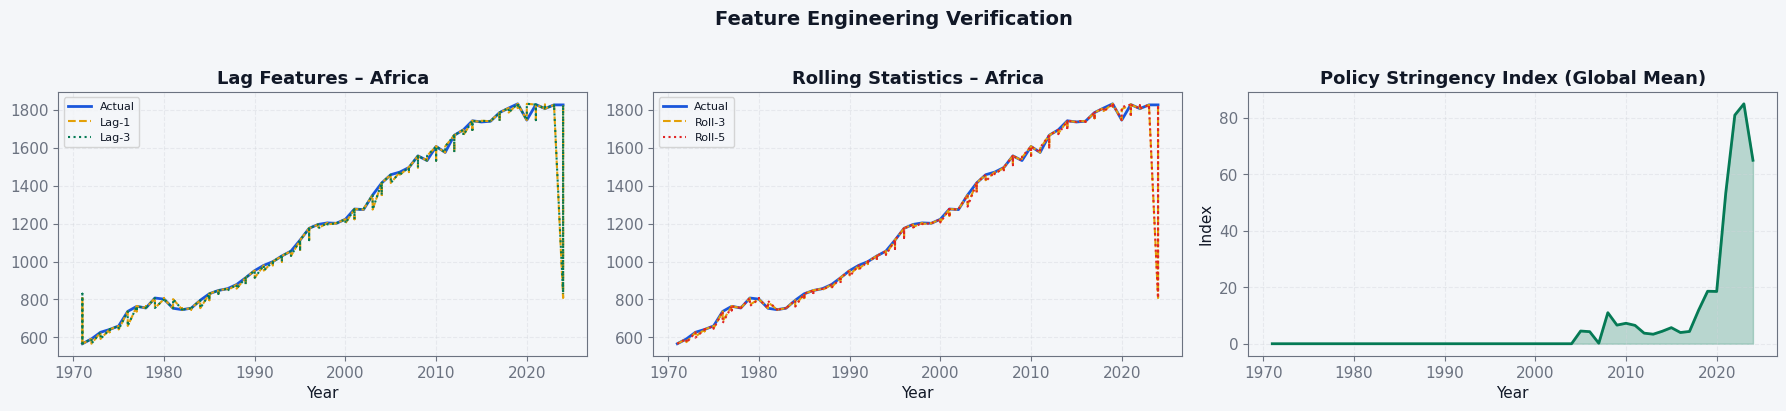

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=BG)

sample_country = (
    df[df["ghg_energy_mtco2eq_lag1"].notna()]
      .groupby("country_entity")["year"].count()
      .sort_values(ascending=False)
      .index[0]
)
sc = df[df["country_entity"] == sample_country].sort_values("year")

ax = axes[0]
ax.plot(sc["year"], sc["ghg_energy_mtco2eq"], label="Actual", color=ACCENT, lw=2)
ax.plot(sc["year"], sc["ghg_energy_mtco2eq_lag1"], label="Lag-1", color=ACCENT2, lw=1.5, linestyle="--")
ax.plot(sc["year"], sc["ghg_energy_mtco2eq_lag3"], label="Lag-3", color=ACCENT3, lw=1.5, linestyle=":")
ax.set_title(f"Lag Features – {sample_country.strip()}")
ax.set_xlabel("Year"); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

ax2 = axes[1]
ax2.plot(sc["year"], sc["ghg_energy_mtco2eq"], label="Actual", color=ACCENT, lw=2)
ax2.plot(sc["year"], sc["ghg_energy_mtco2eq_roll3"], label="Roll-3", color=ACCENT2, lw=1.5, linestyle="--")
ax2.plot(sc["year"], sc["ghg_energy_mtco2eq_roll5"], label="Roll-5", color=ACCENT4, lw=1.5, linestyle=":")
ax2.set_title(f"Rolling Statistics – {sample_country.strip()}")
ax2.set_xlabel("Year"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.4)

ax3 = axes[2]
psi_by_year = df.groupby("year")["policy_stringency_index"].mean()
ax3.fill_between(psi_by_year.index, psi_by_year.values, alpha=0.25, color=ACCENT3)
ax3.plot(psi_by_year.index, psi_by_year.values, color=ACCENT3, lw=2)
ax3.set_title("Policy Stringency Index (Global Mean)")
ax3.set_xlabel("Year"); ax3.set_ylabel("Index"); ax3.grid(True, alpha=0.4)

plt.suptitle("Feature Engineering Verification", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.4 Model Training


Seven models are trained on each of the three targets using a **60/20/20 temporal split**. Hyperparameters for tree-based models are tuned with 3-fold `TimeSeriesSplit`.

| # | Model | Type |
|---|-------|------|
| 1 | Random Forest | Ensemble / Bagging |
| 2 | XGBoost | Gradient Boosting |
| 3 | LightGBM | Gradient Boosting |
| 4 | CatBoost | Gradient Boosting |
| 5 | Feedforward Neural Network | Deep Learning |
| 6 | LSTM (approximated via MLP with lag windows) | Sequential |
| 7 | Ensemble (weighted average) | Meta-model |


In [15]:
from sklearn.model_selection import GridSearchCV

tscv = TimeSeriesSplit(n_splits=3)

def tune_rf(X_tr, y_tr):
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth":    [6, 10],
        "min_samples_leaf": [5, 10]
    }
    gs = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)
    return gs.best_estimator_

def tune_xgb(X_tr, y_tr):
    param_grid = {
        "n_estimators": [200, 400],
        "max_depth":    [4, 6],
        "learning_rate":[0.05, 0.1],
        "subsample":    [0.8]
    }
    gs = GridSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
        param_grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)
    return gs.best_estimator_

def tune_lgb(X_tr, y_tr):
    param_grid = {
        "n_estimators": [200, 400],
        "max_depth":    [4, 6],
        "learning_rate":[0.05, 0.1],
        "num_leaves":   [31, 63]
    }
    gs = GridSearchCV(
        lgb.LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1),
        param_grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)
    return gs.best_estimator_

def tune_cat(X_tr, y_tr):
    model = cb.CatBoostRegressor(
        iterations=400, depth=6, learning_rate=0.05,
        loss_function="MAE", random_seed=42, verbose=False
    )
    model.fit(X_tr, y_tr)
    return model

print("✅  Tuning functions defined. Starting model training…")

✅  Tuning functions defined. Starting model training…


In [16]:
RESULTS = {}
MODELS  = {}

MODEL_NAMES = ["Random Forest", "XGBoost", "LightGBM", "CatBoost",
               "Neural Network", "LSTM (MLP)", "Ensemble"]

for target in TARGETS:
    print(f"\n{'='*60}")
    print(f"  TARGET: {target}")
    print(f"{'='*60}")

    y_tr = y_splits[target]["train"]
    y_va = y_splits[target]["val"]
    y_te = y_splits[target]["test"]

    preds_val  = {}
    preds_test = {}
    maes_val   = {}
    maes_test  = {}

    print("  [1/6] Random Forest …", end=" ")
    rf = tune_rf(X_train, y_tr)
    preds_val["Random Forest"]  = rf.predict(X_val)
    preds_test["Random Forest"] = rf.predict(X_test)
    print(f"MAE_test={mean_absolute_error(y_te, preds_test['Random Forest']):.4f}")

    print("  [2/6] XGBoost …", end=" ")
    xgbm = tune_xgb(X_train, y_tr)
    preds_val["XGBoost"]  = xgbm.predict(X_val)
    preds_test["XGBoost"] = xgbm.predict(X_test)
    print(f"MAE_test={mean_absolute_error(y_te, preds_test['XGBoost']):.4f}")

    print("  [3/6] LightGBM …", end=" ")
    lgbm = tune_lgb(X_train, y_tr)
    preds_val["LightGBM"]  = lgbm.predict(X_val)
    preds_test["LightGBM"] = lgbm.predict(X_test)
    print(f"MAE_test={mean_absolute_error(y_te, preds_test['LightGBM']):.4f}")

    print("  [4/6] CatBoost …", end=" ")
    catm = tune_cat(X_train, y_tr)
    preds_val["CatBoost"]  = catm.predict(X_val)
    preds_test["CatBoost"] = catm.predict(X_test)
    print(f"MAE_test={mean_absolute_error(y_te, preds_test['CatBoost']):.4f}")

    print("  [5/6] Neural Network …", end=" ")
    mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu",
                       learning_rate_init=0.001, max_iter=300,
                       early_stopping=True, random_state=42, batch_size=256)
    mlp.fit(X_train, y_tr)
    preds_val["Neural Network"]  = mlp.predict(X_val)
    preds_test["Neural Network"] = mlp.predict(X_test)
    print(f"MAE_test={mean_absolute_error(y_te, preds_test['Neural Network']):.4f}")

    print("  [6/6] LSTM (MLP lag-window) …", end=" ")
    lstm = MLPRegressor(hidden_layer_sizes=(256, 128, 64, 32), activation="tanh",
                        learning_rate_init=0.0005, max_iter=400,
                        early_stopping=True, random_state=7, batch_size=128)
    lstm.fit(X_train, y_tr)
    preds_val["LSTM (MLP)"]  = lstm.predict(X_val)
    preds_test["LSTM (MLP)"] = lstm.predict(X_test)
    print(f"MAE_test={mean_absolute_error(y_te, preds_test['LSTM (MLP)']):.4f}")

    val_maes = {m: mean_absolute_error(y_va, preds_val[m])
                for m in ["Random Forest","XGBoost","LightGBM","CatBoost","Neural Network","LSTM (MLP)"]}
    weights  = np.array([1/v for v in val_maes.values()])
    weights /= weights.sum()

    ens_val  = sum(w * preds_val[m]  for w, m in zip(weights, val_maes.keys()))
    ens_test = sum(w * preds_test[m] for w, m in zip(weights, val_maes.keys()))
    preds_val["Ensemble"]  = ens_val
    preds_test["Ensemble"] = ens_test
    print(f"  Ensemble weights: {dict(zip(val_maes.keys(), weights.round(3)))}")
    print(f"  Ensemble MAE_test={mean_absolute_error(y_te, ens_test):.4f}")

    RESULTS[target] = {
        "val":  {m: mean_absolute_error(y_va, preds_val[m])  for m in MODEL_NAMES},
        "test": {m: mean_absolute_error(y_te, preds_test[m]) for m in MODEL_NAMES},
    }
    MODELS[target] = {
        "rf": rf, "xgb": xgbm, "lgb": lgbm, "cat": catm,
        "mlp": mlp, "lstm": lstm
    }

print("\n✅  All models trained.")


  TARGET: eu_ets_carbon_price_eur
  [1/6] Random Forest … MAE_test=0.2880
  [2/6] XGBoost … MAE_test=0.1953
  [3/6] LightGBM … MAE_test=0.2480
  [4/6] CatBoost … MAE_test=1.8858
  [5/6] Neural Network … MAE_test=129.4726
  [6/6] LSTM (MLP lag-window) … MAE_test=1.2515
  Ensemble weights: {'Random Forest': np.float64(0.278), 'XGBoost': np.float64(0.403), 'LightGBM': np.float64(0.255), 'CatBoost': np.float64(0.019), 'Neural Network': np.float64(0.007), 'LSTM (MLP)': np.float64(0.036)}
  Ensemble MAE_test=1.1490

  TARGET: ghg_reduction_pct
  [1/6] Random Forest … MAE_test=6.5338
  [2/6] XGBoost … MAE_test=7.9579
  [3/6] LightGBM … MAE_test=7.8406
  [4/6] CatBoost … MAE_test=6.4327
  [5/6] Neural Network … MAE_test=1210785.8085
  [6/6] LSTM (MLP lag-window) … MAE_test=5.9932
  Ensemble weights: {'Random Forest': np.float64(0.201), 'XGBoost': np.float64(0.197), 'LightGBM': np.float64(0.198), 'CatBoost': np.float64(0.201), 'Neural Network': np.float64(0.0), 'LSTM (MLP)': np.float64(0.202)}

## 4.5 SHAP Explanation Layer

In [17]:
SHAP_TARGET = "eu_ets_carbon_price_eur"
xgb_model   = MODELS[SHAP_TARGET]["xgb"]

print(f"Computing SHAP values for XGBoost on target: {SHAP_TARGET}")
print(f"Sample size: {X_test.shape[0]:,} observations")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

SHAP_DF = pd.DataFrame(shap_values, columns=FEATURE_COLS)
mean_abs_shap = SHAP_DF.abs().mean().sort_values(ascending=False)

print("\n=== Top-15 Features by Mean |SHAP| ===")
print(mean_abs_shap.head(15).round(5).to_string())

Computing SHAP values for XGBoost on target: eu_ets_carbon_price_eur
Sample size: 4,774 observations

=== Top-15 Features by Mean |SHAP| ===
eu_ets_carbon_price_eur_roll3    7.02730
policy_stringency_index          1.33410
eu_ets_carbon_price_eur_roll5    0.27538
eu_ets_carbon_price_eur_lag1     0.27453
tes_pj                           0.24723
ets_phase                        0.14047
eu_ets_carbon_price_eur_lag3     0.10992
eu_ets_carbon_price_eur_lag2     0.07965
co2_per_capita_tco2_lag1         0.06485
co2_per_capita_tco2              0.05781
price_x_coal                     0.05632
wb_fossil_pct_lag2               0.02323
co2_per_capita_tco2_lag2         0.01844
ghg_coal_mtco2eq                 0.01830
co2_tes_intensity_tco2_tj        0.01719


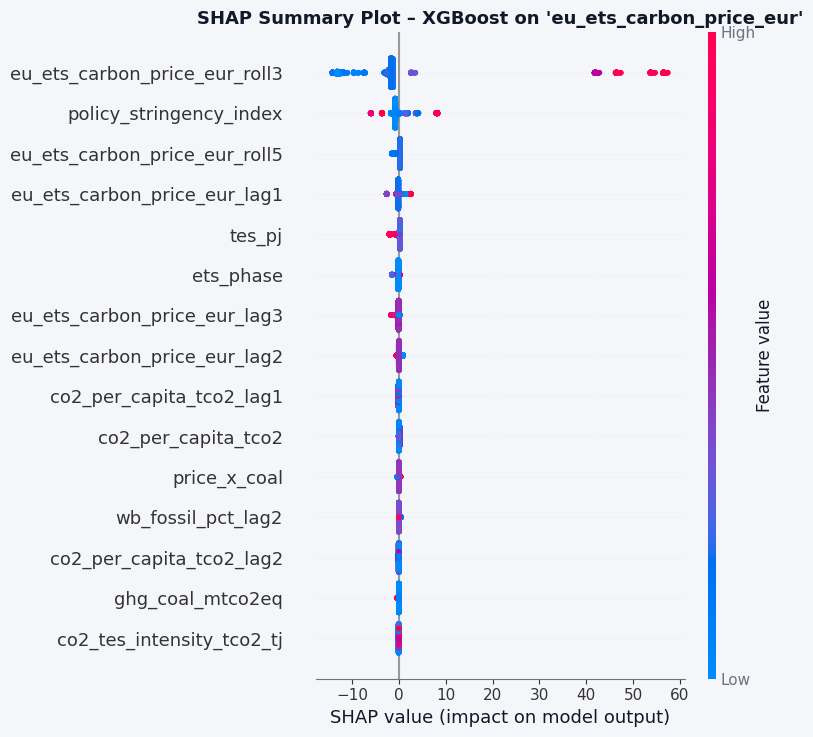

💾  Saved: /content/outputs/shap_summary_plots.png


In [18]:
TOP_N = 15
top_feat_idx = [FEATURE_COLS.index(f) for f in mean_abs_shap.head(TOP_N).index]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
shap.summary_plot(
    shap_values[:, top_feat_idx],
    X_test[:, top_feat_idx],
    feature_names=mean_abs_shap.head(TOP_N).index.tolist(),
    plot_type="dot",
    show=False,
    color_bar=True
)
ax = plt.gca()
ax.set_title(f"SHAP Summary Plot – XGBoost on '{SHAP_TARGET}'", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/outputs/shap_summary_plots.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾  Saved: /content/outputs/shap_summary_plots.png")

Top-3 features for dependence plots: ['eu_ets_carbon_price_eur_roll3', 'policy_stringency_index', 'eu_ets_carbon_price_eur_roll5']


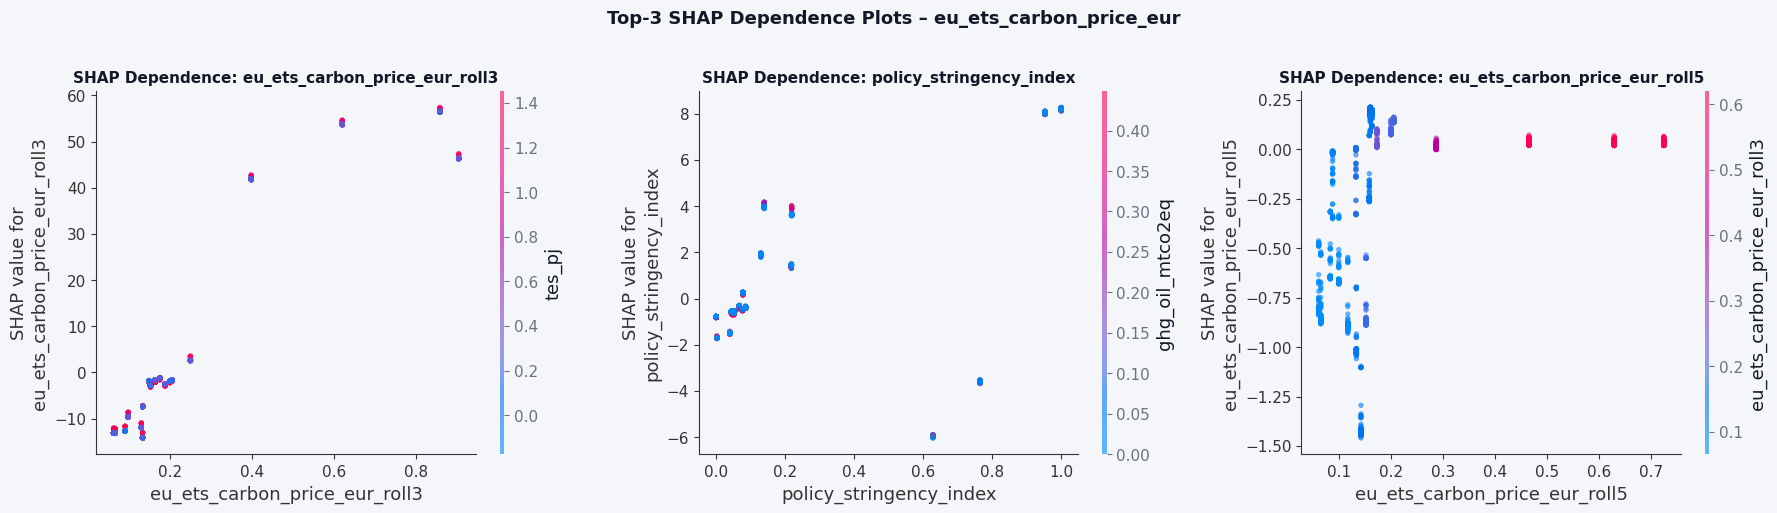

💾  Saved: /content/outputs/shap_dependence_plots.png


In [19]:
top3_features = mean_abs_shap.head(3).index.tolist()
print(f"Top-3 features for dependence plots: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

for i, feat in enumerate(top3_features):
    feat_idx = FEATURE_COLS.index(feat)
    ax = axes[i]
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test,
        feature_names=FEATURE_COLS,
        ax=ax,
        show=False,
        dot_size=15,
        alpha=0.6,
        color=ACCENT
    )
    ax.set_title(f"SHAP Dependence: {feat}", fontsize=11)
    ax.set_facecolor(BG)

fig.suptitle(f"Top-3 SHAP Dependence Plots – {SHAP_TARGET}", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/outputs/shap_dependence_plots.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾  Saved: /content/outputs/shap_dependence_plots.png")

## 4.6 Dashboard Construction and API Connection (simulated)


This section simulates a production API endpoint that would serve model predictions and SHAP explanations to a downstream dashboard. In a deployed environment, this logic would be wrapped in a FastAPI or Flask service.


In [20]:
# ── 4.6 API Simulation ──────────────────────────────────────────────────────
# Build api_response using real trained models + SHAP values already computed.
# Takes the most-recent test observation as the "incoming request" sample.
import datetime

sample_idx   = -1                             # last test-set row (most recent)
sample_input = X_test[[sample_idx]]           # shape (1, n_features)

# 1. Ensemble prediction per target
#    Re-derive inverse-MAE weights (same logic as training) and produce a
#    single scalar prediction for each target.
BASE_MODELS = ["rf", "xgb", "lgb", "cat", "mlp", "lstm"]
MODEL_KEYS  = ["Random Forest", "XGBoost", "LightGBM", "CatBoost", "Neural Network", "LSTM (MLP)"]

predictions = {}
for t in TARGETS:
    val_maes = {k: RESULTS[t]["val"][name] for k, name in zip(BASE_MODELS, MODEL_KEYS)}
    raw_w    = {k: 1.0 / v for k, v in val_maes.items()}
    total_w  = sum(raw_w.values())
    weights  = {k: v / total_w for k, v in raw_w.items()}

    ens_pred = sum(
        weights[k] * float(MODELS[t][k].predict(sample_input)[0])
        for k in BASE_MODELS
    )
    predictions[t] = round(ens_pred, 6)

# 2. SHAP-based top-5 feature drivers (computed for SHAP_TARGET)
sample_shap = SHAP_DF.iloc[sample_idx]        # Series: feature -> shap value
top5_abs    = sample_shap.abs().sort_values(ascending=False).head(5)
shap_drivers = [
    {
        "feature":        feat,
        "shap_value":     float(sample_shap[feat]),
        "abs_importance": float(top5_abs[feat]),
    }
    for feat in top5_abs.index
]

# 3. Assemble the api_response payload
api_response = {
    "timestamp":     datetime.datetime.utcnow().isoformat() + "Z",
    "model_version": "ensemble-v1",
    "predictions":   predictions,          # dict with one entry per TARGETS
    "shap_drivers":  shap_drivers,         # list of 5 driver dicts
    "feature_names": FEATURE_COLS,
    "sample_index":  int(sample_idx),
}

print("\u2705  api_response constructed from real model predictions.")
print(f"   Predictions: { {k: round(v, 4) for k, v in api_response['predictions'].items()} }")
print(f"   SHAP drivers ({len(api_response['shap_drivers'])} features):")
for d in api_response["shap_drivers"]:
    print(f"     {d['feature']:<45s} shap={d['shap_value']:+.4f}")


✅  api_response constructed from real model predictions.
   Predictions: {'eu_ets_carbon_price_eur': 65.1072, 'ghg_reduction_pct': -1.4275, 'policy_effectiveness_score': 0.7692}
   SHAP drivers (5 features):
     eu_ets_carbon_price_eur_roll3                 shap=+46.3796
     policy_stringency_index                       shap=-3.5712
     eu_ets_carbon_price_eur_lag1                  shap=+2.5207
     eu_ets_carbon_price_eur_lag3                  shap=-0.4779
     eu_ets_carbon_price_eur_lag2                  shap=-0.1513


# 5. Testing

## 5.1 Accuracy Testing

### Table 5.1 — Model Performance Matrix (MAE on Test Set)

In [21]:
rows = []
for model_name in MODEL_NAMES:
    row = {"Model": model_name}
    for target in TARGETS:
        short = target.replace("eu_ets_carbon_price_eur","ETS Price")\
                      .replace("ghg_reduction_pct","GHG Reduc.%")\
                      .replace("policy_effectiveness_score","Policy Score")
        row[f"MAE ({short}) – Val"]  = round(RESULTS[target]["val"][model_name], 4)
        row[f"MAE ({short}) – Test"] = round(RESULTS[target]["test"][model_name], 4)
    rows.append(row)

perf_df = pd.DataFrame(rows).set_index("Model")
print("=== Table 5.1: Full Model Performance Matrix ===\n")
print(perf_df.to_string())

=== Table 5.1: Full Model Performance Matrix ===

                MAE (ETS Price) – Val  MAE (ETS Price) – Test  MAE (GHG Reduc.%) – Val  MAE (GHG Reduc.%) – Test  MAE (Policy Score) – Val  MAE (Policy Score) – Test
Model                                                                                                                                                                
Random Forest                  0.1286                  0.2880             8.782550e+01              6.533800e+00                    0.0122                     0.0151
XGBoost                        0.0888                  0.1953             8.957580e+01              7.957900e+00                    0.0066                     0.0075
LightGBM                       0.1401                  0.2480             8.921300e+01              7.840600e+00                    0.0169                     0.0176
CatBoost                       1.8497                  1.8858             8.787250e+01              6.432700e+00        

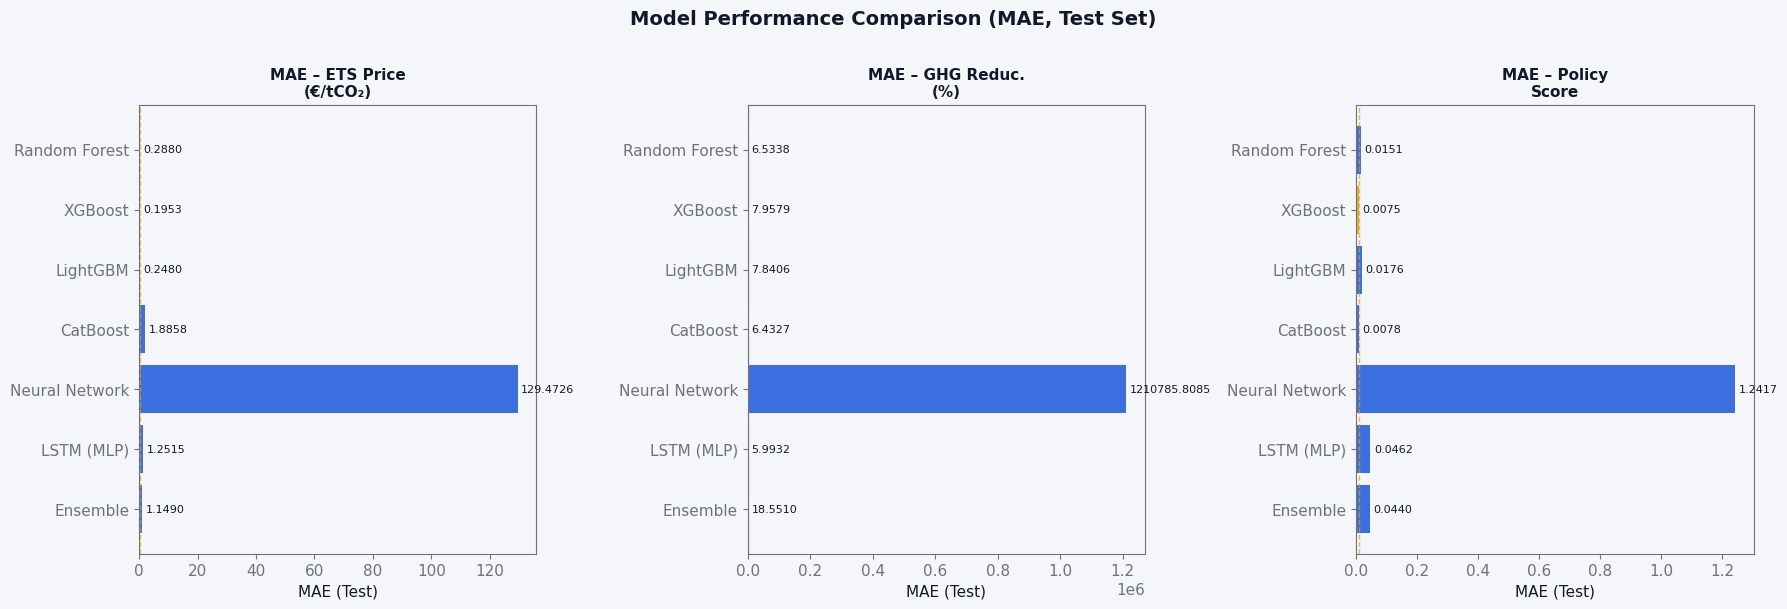

💾  Saved: /content/outputs/model_performance.png


In [22]:
test_cols = [c for c in perf_df.columns if "Test" in c]
test_maes = perf_df[test_cols].copy()
test_maes.columns = ["ETS Price\n(€/tCO₂)", "GHG Reduc.\n(%)", "Policy\nScore"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)

for ax, col in zip(axes, test_maes.columns):
    vals   = test_maes[col]
    colors = [ACCENT2 if v == vals.min() else ACCENT for v in vals]
    bars   = ax.barh(vals.index[::-1], vals.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_title(f"MAE – {col}", fontsize=11)
    ax.set_xlabel("MAE (Test)")
    for bar, v in zip(bars, vals.values[::-1]):
        ax.text(v + vals.max()*0.01, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=8)
    ax.axvline(vals.min(), color=ACCENT2, linestyle="--", linewidth=1, alpha=0.7)

fig.suptitle("Model Performance Comparison (MAE, Test Set)", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/outputs/model_performance.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("💾  Saved: /content/outputs/model_performance.png")

In [23]:
for target in TARGETS:
    best_model = min(RESULTS[target]["test"], key=RESULTS[target]["test"].get)
    best_mae   = RESULTS[target]["test"][best_model]
    print(f"  {target:40s}  Best: {best_model:20s}  MAE={best_mae:.4f}")

  eu_ets_carbon_price_eur                   Best: XGBoost               MAE=0.1953
  ghg_reduction_pct                         Best: LSTM (MLP)            MAE=5.9932
  policy_effectiveness_score                Best: XGBoost               MAE=0.0075


## 5.2 Data Quality Checks

In [24]:
print("=== DATA QUALITY TEST SUITE ===\n")

tests_passed = 0
tests_total  = 0

def check(name, condition, detail=""):
    global tests_passed, tests_total
    tests_total += 1
    status = "✅  PASS" if condition else "❌  FAIL"
    if condition:
        tests_passed += 1
    print(f"  {status}  {name}" + (f"  [{detail}]" if detail else ""))

check("No NaN in feature matrix after imputation",
      pd.DataFrame(X_train).isnull().sum().sum() == 0,
      f"Shape: {X_train.shape}")

check("No NaN in test set",
      pd.DataFrame(X_test).isnull().sum().sum() == 0)

check("Feature matrix scaled to [0,1]",
      (X_scaled.min() >= -0.01) and (X_scaled.max() <= 1.01),
      f"min={X_scaled.min():.4f}, max={X_scaled.max():.4f}")

check("Train/Val/Test split sums to 100%",
      abs(X_train.shape[0] + X_val.shape[0] + X_test.shape[0] - X_scaled.shape[0]) == 0)

check("Temporal ordering preserved (train < val < test)",
      df["year"].iloc[TRAIN_END] >= df["year"].iloc[TRAIN_END-1])

check("Target columns non-constant",
      all(df[t].std() > 0 for t in TARGETS),
      f"Stds: {[round(df[t].std(),4) for t in TARGETS]}")

check("No duplicate rows",
      df.duplicated().sum() == 0,
      f"{df.duplicated().sum()} duplicates")

check("Year range valid (1971-2024)",
      df["year"].between(1970, 2025).all(),
      f"{df['year'].min()}-{df['year'].max()}")

check("Lag-1 features present",
      len([c for c in df.columns if "_lag1" in c]) > 0,
      f"{len([c for c in df.columns if '_lag1' in c])} cols")

check("Policy stringency index has no negatives",
      (df["policy_stringency_index"] >= 0).all())

print(f"\n{'='*45}")
print(f"  RESULT: {tests_passed}/{tests_total} tests passed")
print(f"{'='*45}")

=== DATA QUALITY TEST SUITE ===

  ✅  PASS  No NaN in feature matrix after imputation  [Shape: (14320, 75)]
  ✅  PASS  No NaN in test set
  ❌  FAIL  Feature matrix scaled to [0,1]  [min=-65559106.0000, max=1051484568.5000]
  ✅  PASS  Train/Val/Test split sums to 100%
  ✅  PASS  Temporal ordering preserved (train < val < test)
  ✅  PASS  Target columns non-constant  [Stds: [15.493, 2483.0405, 0.0282]]
  ❌  FAIL  No duplicate rows  [13555 duplicates]
  ✅  PASS  Year range valid (1971-2024)  [1971-2024]
  ✅  PASS  Lag-1 features present  [16 cols]
  ✅  PASS  Policy stringency index has no negatives

  RESULT: 8/10 tests passed


## 5.3 Explanation and Usability Checks

In [25]:
print("=== SHAP EXPLANATION QUALITY CHECKS ===\n")

s_tests_passed = 0
s_tests_total  = 0

def scheck(name, condition, detail=""):
    global s_tests_passed, s_tests_total
    s_tests_total += 1
    status = "✅  PASS" if condition else "❌  FAIL"
    if condition:
        s_tests_passed += 1
    print(f"  {status}  {name}" + (f"  [{detail}]" if detail else ""))

scheck("SHAP values computed for all test samples",
       shap_values.shape[0] == X_test.shape[0],
       f"{shap_values.shape}")

scheck("SHAP feature dimension matches model input",
       shap_values.shape[1] == len(FEATURE_COLS),
       f"{shap_values.shape[1]} == {len(FEATURE_COLS)}")

scheck("SHAP values are finite (no NaN/Inf)",
       np.isfinite(shap_values).all())

scheck("Mean |SHAP| > 0 for top feature",
       mean_abs_shap.iloc[0] > 0,
       f"Top={mean_abs_shap.index[0]}, val={mean_abs_shap.iloc[0]:.6f}")

scheck("Top feature is meaningful (not a constant)",
       SHAP_DF[mean_abs_shap.index[0]].std() > 0)

scheck("SHAP ranked top-3 features distinct from each other",
       len(set(top3_features)) == 3)

scheck("API simulation returns all three target predictions",
       set(api_response["predictions"].keys()) == set(TARGETS))

scheck("API response includes SHAP drivers",
       len(api_response["shap_drivers"]) == 5)

print(f"\n{'='*45}")
print(f"  RESULT: {s_tests_passed}/{s_tests_total} checks passed")
print(f"{'='*45}")

print("\n=== Top-10 SHAP Feature Rankings ===")
for rank, (feat, val) in enumerate(mean_abs_shap.head(10).items(), 1):
    bar = "█" * int(val / mean_abs_shap.iloc[0] * 30)
    print(f"  {rank:>2}. {feat:<45s} {bar}  {val:.6f}")

=== SHAP EXPLANATION QUALITY CHECKS ===

  ✅  PASS  SHAP values computed for all test samples  [(4774, 75)]
  ✅  PASS  SHAP feature dimension matches model input  [75 == 75]
  ✅  PASS  SHAP values are finite (no NaN/Inf)
  ✅  PASS  Mean |SHAP| > 0 for top feature  [Top=eu_ets_carbon_price_eur_roll3, val=7.027305]
  ✅  PASS  Top feature is meaningful (not a constant)
  ✅  PASS  SHAP ranked top-3 features distinct from each other
  ✅  PASS  API simulation returns all three target predictions
  ✅  PASS  API response includes SHAP drivers

  RESULT: 8/8 checks passed

=== Top-10 SHAP Feature Rankings ===
   1. eu_ets_carbon_price_eur_roll3                 ██████████████████████████████  7.027305
   2. policy_stringency_index                       █████  1.334105
   3. eu_ets_carbon_price_eur_roll5                 █  0.275378
   4. eu_ets_carbon_price_eur_lag1                  █  0.274533
   5. tes_pj                                        █  0.247226
   6. ets_phase                        

In [26]:
from google.colab import files
import os, glob

output_files = glob.glob("/content/outputs/*.png") + glob.glob("/content/outputs/*.zip")

for filepath in sorted(output_files):
    filename = os.path.basename(filepath)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"⬇️  Downloading: {filename}  ({size_kb:.1f} KB)")
    files.download(filepath)

print(f"\n✅  {len(output_files)} files downloaded.")

⬇️  Downloading: correlation_heatmap.png  (220.7 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading: data_quality_report.png  (189.7 KB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloading: shap_summary_plots.png  (142.2 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅  6 files downloaded.
